In [1]:
import numpy as np
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDRegressor
import matplotlib.pyplot as plt

from data import CaseHFL

In [2]:
rng = np.random.default_rng(42)
case = CaseHFL(
    rng = rng,
    n = 1000,
    events = 100,
    output_arity = 50,
    sensors = 10,
    noise_std = 0.01
)

X_train, Y_train = case.generate_data()
X_test, Y_test = case.generate_data()
print(len(X_train)) # 10 x 100 x 100

10


In [3]:
X_train_agg = np.block([x for x in X_train]).T 
Y_train_agg = np.concatenate(Y_train)

X_test_agg = np.block([x for x in X_test]).T
Y_test_agg = np.concatenate(Y_test)

model = Ridge(alpha=0.5).fit(X_train_agg, Y_train_agg)
Y_train_pred = model.predict(X_train_agg)
print(f"Train Error: {mean_squared_error(Y_train_pred, Y_train_agg)}")
Y_test_pred = model.predict(X_test_agg)
print(f"Test Error: {mean_squared_error(Y_test_pred, Y_test_agg)}")

Train Error: 9.11065618121719e-05
Test Error: 0.00011959060203506153


## FedAVG

In [4]:
def _fedavg(X_train, Y_train, X_test=None, Y_test=None, iterations=10, alpha=0.5, initial_lr=1e-4):
    n_features = X_train[0].shape[0]
    n_sensors = len(X_train)
    
    global_weights = np.zeros(n_features)
    global_intercept = np.zeros(1)
    mse_history = []

    for _ in range(iterations):
        local_weights_list = []
        local_intercept_list = []

        for s in range(n_sensors):
            X_local = X_train[s].T 
            Y_local = Y_train[s]

            local_model = SGDRegressor(
                loss='squared_error', 
                penalty='l2', 
                alpha=alpha, 
                learning_rate='invscaling',
                eta0=initial_lr
            )
            local_model.coef_ = global_weights.copy()
            local_model.intercept_ = global_intercept.copy()

            local_model.partial_fit(X_local, Y_local)

            local_weights_list.append(local_model.coef_)
            local_intercept_list.append(local_model.intercept_)

        global_weights = np.mean(local_weights_list, axis=0)
        global_intercept = np.mean(local_intercept_list, axis=0)

        if X_test is not None and Y_test is not None:
            cur_mse = evaluate_global_model(global_weights, global_intercept, X_test, Y_test)
            mse_history.append(cur_mse)

    return global_weights, global_intercept, mse_history

In [5]:
def federated_averaging(X_train, Y_train, iterations=10, alpha=0.5, initial_lr=1e-4):
    w, b, _ = _fedavg(X_train, Y_train, iterations=iterations, alpha=alpha, initial_lr=initial_lr)
    return w, b

def federated_averaging_with_history(X_train, Y_train, X_test, Y_test, iterations=10, alpha=0.5, initial_lr=1e-4):
    return _fedavg(X_train, Y_train, X_test, Y_test, iterations, alpha, initial_lr)

In [6]:
def evaluate_global_model(weights, intercept, X_test, Y_test):
    X_test_global = np.block([x for x in X_test]).T
    Y_test_global = np.concatenate(Y_test)

    predictions = (X_test_global @ weights) + intercept
    
    mse = mean_squared_error(Y_test_global, predictions)
    return mse

In [9]:
def plot_mse_vs_alpha(alphas, X_train, Y_train, X_test, Y_test, iterations):
    mse_results = []

    for a in alphas:
        weights, intercept = federated_averaging(X_train, Y_train, alpha=a, iterations=iterations)
        
        mse = evaluate_global_model(weights, intercept, X_test, Y_test)
        mse_results.append(mse)

    plt.plot(alphas, mse_results, marker='o', linestyle='-', color='b')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Alpha (Ridge Regularization Strength)')
    plt.ylabel('Test MSE')
    plt.title('FedAvg: Test MSE vs. Alpha')
    plt.show()

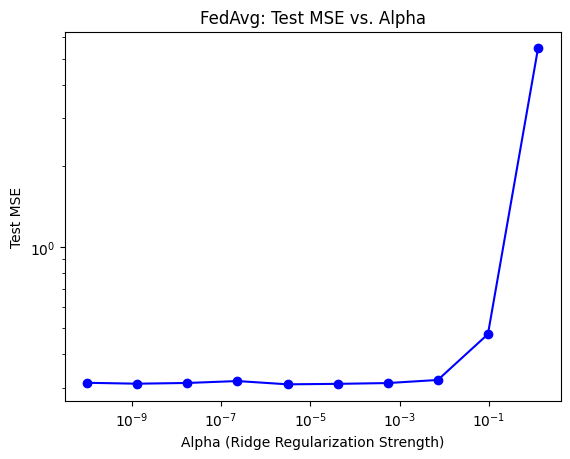

In [13]:
alpha_range = np.logspace(start=-10, stop=0.1, num=10)
plot_mse_vs_alpha(alpha_range, X_train, Y_train, X_test, Y_test, iterations=500)

In [16]:
def plot_mse_vs_iterations(X_train, Y_train, X_test, Y_test, iterations=100, alpha=0.5):
    _, _, mse_history = federated_averaging_with_history(
        X_train, Y_train, X_test, Y_test, iterations=iterations, alpha=alpha
    )

    plt.plot(range(1, len(mse_history) + 1), mse_history, color='b')
    plt.yscale('log')
    plt.xlabel('Number of Iterations')
    plt.ylabel('Test MSE')
    plt.title(f'MSE vs. Iterations (Alpha={alpha})')
    plt.show()

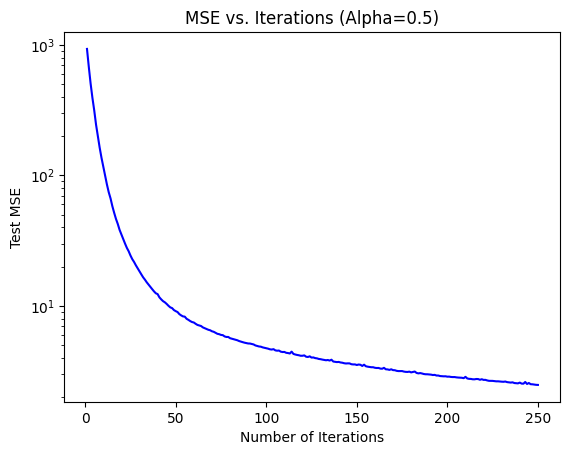

In [18]:
plot_mse_vs_iterations(X_train, Y_train, X_test, Y_test, iterations=250)